# 60 veces más selectiva que la mediana. ¿Cómo?

Una membrana de vidrio inspirada en proteínas de transporte iónico separa litio del potasio con una selectividad K⁺/Li⁺ de 410 en salmueras multi-iónicas — y lo hace con solo 1,02 kWh por kg de Li₂CO₃.

---

**Paper:** Wu, J. et al. "Scalable glass composite membranes for highly selective lithium enrichment." *Nature Water* (2026).
**DOI:** [10.1038/s44221-026-00633-w](https://doi.org/10.1038/s44221-026-00633-w)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-14-membranas-selectivas-litio/notebook.ipynb)

**Video:** [Pendiente]

## El problema del litio

El litio es el corazón de las baterías que mueven autos eléctricos y almacenan energía renovable. Pero en la naturaleza, el litio está mezclado con sodio y potasio — iones químicamente tan parecidos que separarlos es como distinguir gemelos en una multitud.

El desafío técnico: el litio desnudo (sin agua) mide apenas 0,12 nm, pero rodeado de su capa de agua (hidratado) se convierte en el ión monovalente **más grande** (0,76 nm). Esa paradoja es la clave de esta membrana.

Un equipo diseñó canales sub-nanométricos de vidrio MOF (metal-organic framework) que explotan esa diferencia. Veamos qué tan lejos llegan.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ISGC_KLI_BINARY = 185       # Selectividad K⁺/Li⁺ en mezcla binaria 1:1
ISGC_NALI_BINARY = 53.3     # Selectividad Na⁺/Li⁺ en mezcla binaria 1:1
ISGC_ENERGY = 1.02           # kWh/kg de Li₂CO₃
LI_ENRICHMENT = 64.6         # g/L de Li⁺ en permeado final
FUENTE = 'Fuente: Wu et al. (2026), Nature Water | Datos: Supplementary Tables S1-S6'

COLOR_ISGC = '#2563EB'       # Azul CaM — ISGC (este trabajo)
COLOR_ALERTA = '#DC2626'     # Rojo — referencia/alerta
COLOR_SECUNDARIO = '#059669' # Emerald — datos secundarios
COLOR_REFERENCIA = '#D97706' # Amber — umbrales
COLOR_VIOLETA = '#7C3AED'    # Violeta — correlaciones
COLOR_GRIS = '#BBBBBB'       # Gris — competidores

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
sel = pd.read_csv('datos/selectividad_membranas.csv')
ions = pd.read_csv('datos/especies_ionicas.csv')
pals = pd.read_csv('datos/pals_membranas.csv')
metodos = pd.read_csv('datos/comparacion_metodos.csv')
capex = pd.read_csv('datos/capex.csv')

print(f"Datos cargados:")
print(f"  Selectividad: {len(sel)} materiales")
print(f"  Especies iónicas: {len(ions)} iones")
print(f"  PALS (estructura de poro): {len(pals)} composiciones")
print(f"  Métodos de extracción: {len(metodos)} métodos")
print(f"  CAPEX: {len(capex)} componentes")

Datos cargados:
  Selectividad: 11 materiales
  Especies iónicas: 6 iones
  PALS (estructura de poro): 5 composiciones
  Métodos de extracción: 6 métodos
  CAPEX: 6 componentes


## ¿Cuánto mejor es esta membrana?

Aquí está.

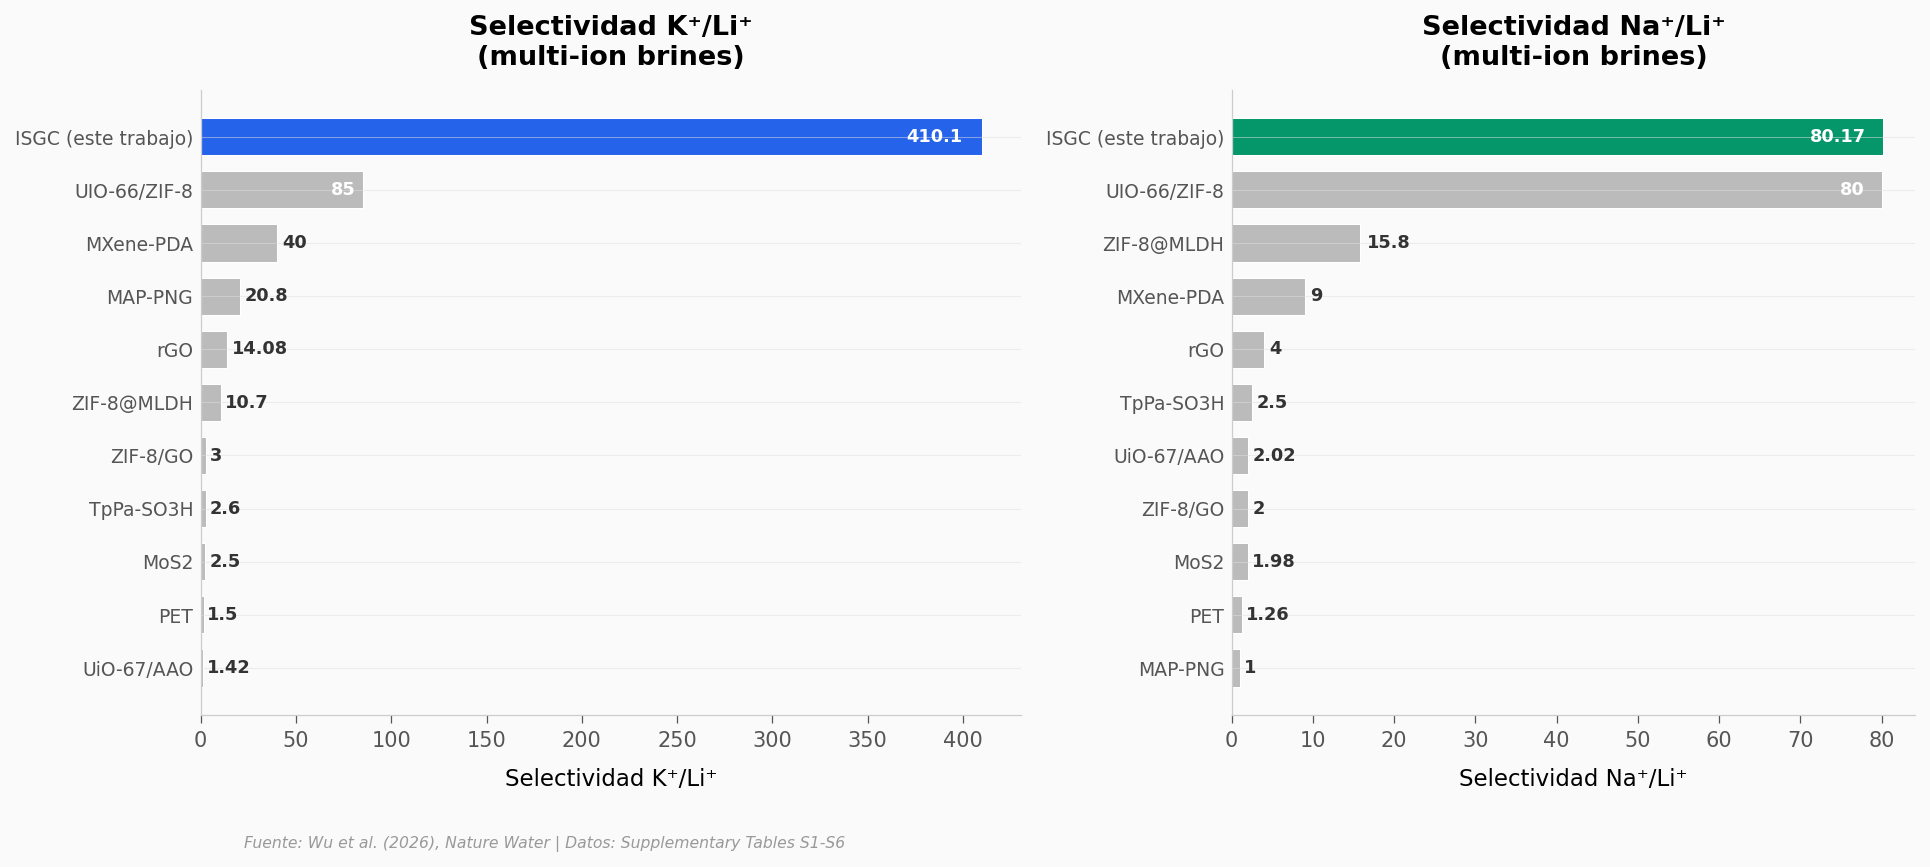

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.2, 1]})

# Ordenar por K⁺/Li⁺
sel_sorted = sel.sort_values('k_li_selectivity')
colors = [COLOR_ISGC if 'ISGC' in m else COLOR_GRIS for m in sel_sorted['material']]

# Panel izquierdo: K⁺/Li⁺
bars1 = ax1.barh(range(len(sel_sorted)), sel_sorted['k_li_selectivity'],
                 color=colors, edgecolor='white', linewidth=0.5, height=0.7)
ax1.set_yticks(range(len(sel_sorted)))
ax1.set_yticklabels(sel_sorted['material'], fontsize=9)
ax1.set_xlabel('Selectividad K⁺/Li⁺', fontsize=11)
ax1.set_title('Selectividad K⁺/Li⁺\n(multi-ion brines)',
              fontsize=13, fontweight='bold', pad=12)

# Inline labels
for i, (val, mat) in enumerate(zip(sel_sorted['k_li_selectivity'], sel_sorted['material'])):
    offset = val * 0.02 + 2
    color = 'white' if val > 50 else '#333333'
    ha = 'right' if val > 50 else 'left'
    x = val - offset if val > 50 else val + offset
    ax1.text(x, i, f'{val:g}', va='center', ha=ha, fontsize=8.5,
             fontweight='bold', color=color)

# Panel derecho: Na⁺/Li⁺
sel_sorted2 = sel.sort_values('na_li_selectivity')
colors2 = [COLOR_SECUNDARIO if 'ISGC' in m else COLOR_GRIS for m in sel_sorted2['material']]
bars2 = ax2.barh(range(len(sel_sorted2)), sel_sorted2['na_li_selectivity'],
                 color=colors2, edgecolor='white', linewidth=0.5, height=0.7)
ax2.set_yticks(range(len(sel_sorted2)))
ax2.set_yticklabels(sel_sorted2['material'], fontsize=9)
ax2.set_xlabel('Selectividad Na⁺/Li⁺', fontsize=11)
ax2.set_title('Selectividad Na⁺/Li⁺\n(multi-ion brines)',
              fontsize=13, fontweight='bold', pad=12)

for i, (val, mat) in enumerate(zip(sel_sorted2['na_li_selectivity'], sel_sorted2['material'])):
    offset = val * 0.02 + 0.5
    color = 'white' if val > 20 else '#333333'
    ha = 'right' if val > 20 else 'left'
    x = val - offset if val > 20 else val + offset
    ax2.text(x, i, f'{val:g}', va='center', ha=ha, fontsize=8.5,
             fontweight='bold', color=color)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/selectividad_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia es abismal. La membrana ISGC alcanza una selectividad K⁺/Li⁺ de 410 en salmueras multi-iónicas — 4,8 veces más que el mejor competidor (UIO-66/ZIF-8, que logra 85) y 60 veces más que la mediana del campo (6,8).

Para Na⁺/Li⁺, el salto es menos dramático: ISGC y UIO-66/ZIF-8 están prácticamente igualados (~80). Pero la verdadera prueba de fuego es el potasio — el ión más difícil de separar del litio — y ahí ISGC aplasta a los 10 materiales comparados.

¿Qué truco usa? No es un diseño arbitrario: está inspirado en cómo las células vivas filtran iones.

## La paradoja del litio: pequeño pero grande

Cuando un ión se disuelve en agua, se rodea de una capa de moléculas de agua — su *capa de hidratación*. El litio, al ser tan pequeño (0,12 nm desnudo), atrae agua con más fuerza que el sodio o el potasio. Resultado: el ión más pequeño se convierte en el más grande cuando está hidratado.

La membrana ISGC explota esa diferencia. Sus poros de ~2,7 Å fuerzan a los iones a perder parte de su capa de agua para pasar. El potasio (hidratado: 0,66 nm) la pierde fácil y pasa rápido. El litio (hidratado: 0,76 nm) se resiste — y eso es lo que da la selectividad.

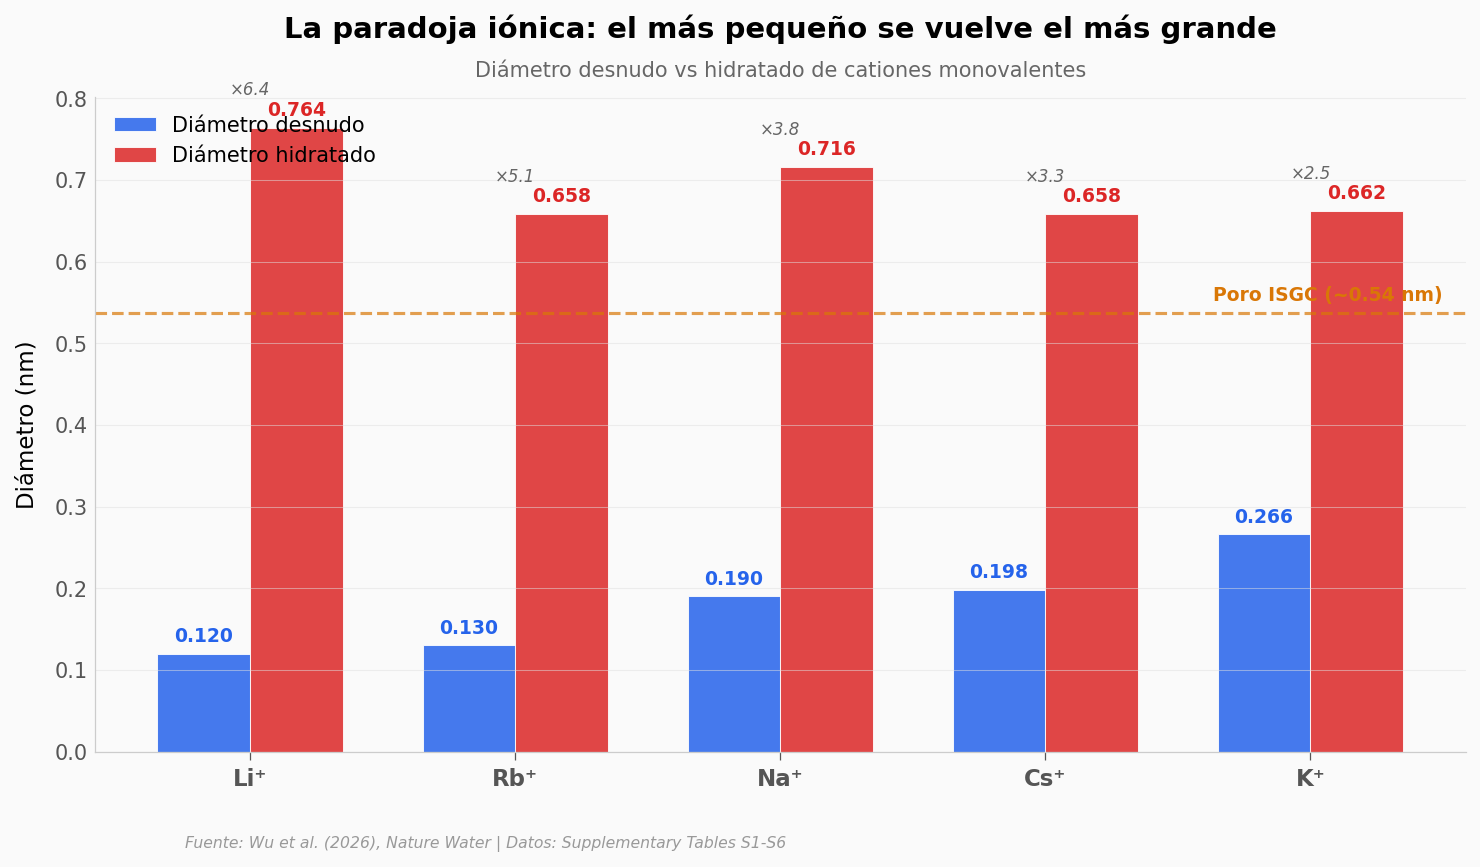

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Filtrar solo los cationes monovalentes relevantes
cations = ions[ions['ion'].isin(['Li+', 'Na+', 'K+', 'Rb+', 'Cs+'])].copy()
cations_sorted = cations.sort_values('bare_diameter_nm')

x = np.arange(len(cations_sorted))
width = 0.35

bars_bare = ax.bar(x - width/2, cations_sorted['bare_diameter_nm'],
                   width, label='Diámetro desnudo', color=COLOR_ISGC, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
bars_hyd = ax.bar(x + width/2, cations_sorted['hydrated_diameter_nm'],
                  width, label='Diámetro hidratado', color=COLOR_ALERTA, alpha=0.85,
                  edgecolor='white', linewidth=0.5)

# Inline labels
for bar in bars_bare:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, color=COLOR_ISGC, fontweight='bold')
for bar in bars_hyd:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, color=COLOR_ALERTA, fontweight='bold')

# Ratios de hidratación
for i, (_, row) in enumerate(cations_sorted.iterrows()):
    ratio = row['hydrated_diameter_nm'] / row['bare_diameter_nm']
    ax.text(i, row['hydrated_diameter_nm'] + 0.04, f'×{ratio:.1f}',
            ha='center', fontsize=8, color='#666666', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(cations_sorted['ion'].str.replace('+', '⁺'), fontsize=11, fontweight='bold')
ax.set_ylabel('Diámetro (nm)', fontsize=11)
ax.set_title('La paradoja iónica: el más pequeño se vuelve el más grande',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Diámetro desnudo vs hidratado de cationes monovalentes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

# Zona del poro ISGC
pore_r = 2.686  # Å = 0.2686 nm radius → diameter = 0.5372 nm
pore_d = pore_r * 2 / 10  # Convert Å to nm
ax.axhline(y=pore_d, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(len(cations_sorted) - 0.5, pore_d + 0.015,
        f'Poro ISGC (~{pore_d:.2f} nm)', fontsize=9,
        color=COLOR_REFERENCIA, fontweight='bold', ha='right')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/paradoja_ionica.png', dpi=200, bbox_inches='tight')
plt.show()

## El punto justo: ni muy cerrado ni muy abierto

La membrana se fabrica mezclando dos materiales: ZIF-62 (la matriz de vidrio) y ZIF-8 (que crea los poros). ¿Cuánto ZIF-8 hay que agregar? Poco y los poros son demasiado pequeños — nada pasa. Mucho y los poros se abren tanto que pierden selectividad.

La espectroscopía PALS (positron annihilation lifetime) midió el tamaño exacto de los poros para 5 composiciones.

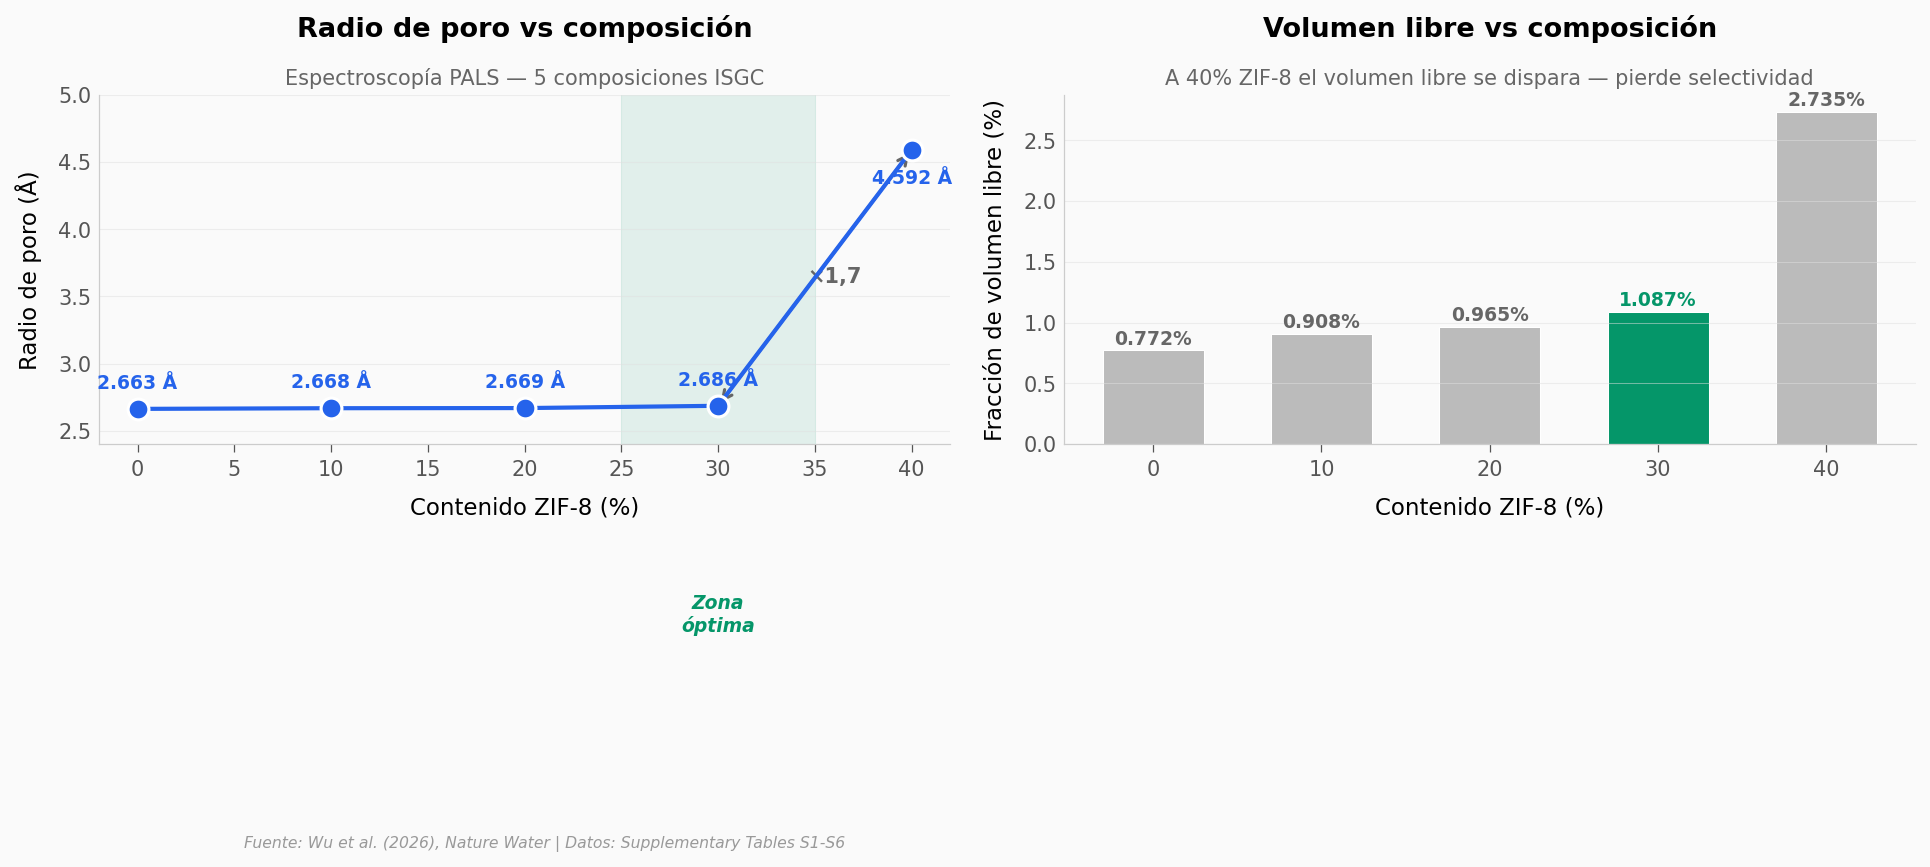

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

zif8_pct = pals['zif8_ratio'] * 100
labels = [f'{int(r)}%' for r in zif8_pct]

# Panel izquierdo: Radio de poro
ax1.plot(zif8_pct, pals['r_angstrom'], 'o-', color=COLOR_ISGC,
         markersize=10, linewidth=2, markeredgecolor='white', markeredgewidth=1.5, zorder=5)
ax1.fill_between([25, 35], 0, 6, alpha=0.1, color=COLOR_SECUNDARIO, zorder=0)
ax1.text(30, 1.0, 'Zona\nóptima', ha='center', fontsize=9,
         color=COLOR_SECUNDARIO, fontweight='bold', style='italic')

for i, (x, y, label) in enumerate(zip(zif8_pct, pals['r_angstrom'], labels)):
    offset_y = 0.15 if i < 4 else -0.25
    ax1.text(x, y + offset_y, f'{y:.3f} Å', ha='center', fontsize=9,
             color=COLOR_ISGC, fontweight='bold')

ax1.set_xlabel('Contenido ZIF-8 (%)', fontsize=11)
ax1.set_ylabel('Radio de poro (Å)', fontsize=11)
ax1.set_title('Radio de poro vs composición',
              fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Espectroscopía PALS — 5 composiciones ISGC',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')
ax1.set_ylim(2.4, 5.0)

# Marcar el salto 30% → 40%
ax1.annotate('', xy=(40, 4.592), xytext=(30, 2.686),
             arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax1.text(36, 3.6, '×1,7', fontsize=10, color='#666666', fontweight='bold', ha='center')

# Panel derecho: FFV
ax2.bar(zif8_pct, pals['ffv_pct'], width=6,
        color=[COLOR_SECUNDARIO if r == 0.3 else COLOR_GRIS for r in pals['zif8_ratio']],
        edgecolor='white', linewidth=0.5)

for x, y in zip(zif8_pct, pals['ffv_pct']):
    ax2.text(x, y + 0.05, f'{y:.3f}%', ha='center', fontsize=9, fontweight='bold',
             color=COLOR_SECUNDARIO if x == 30 else '#666666')

ax2.set_xlabel('Contenido ZIF-8 (%)', fontsize=11)
ax2.set_ylabel('Fracción de volumen libre (%)', fontsize=11)
ax2.set_title('Volumen libre vs composición',
              fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'A 40% ZIF-8 el volumen libre se dispara — pierde selectividad',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/estructura_poro.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y la energía?

Separar litio no solo tiene que ser selectivo — tiene que ser barato.

¿Cuánta energía gasta cada método?

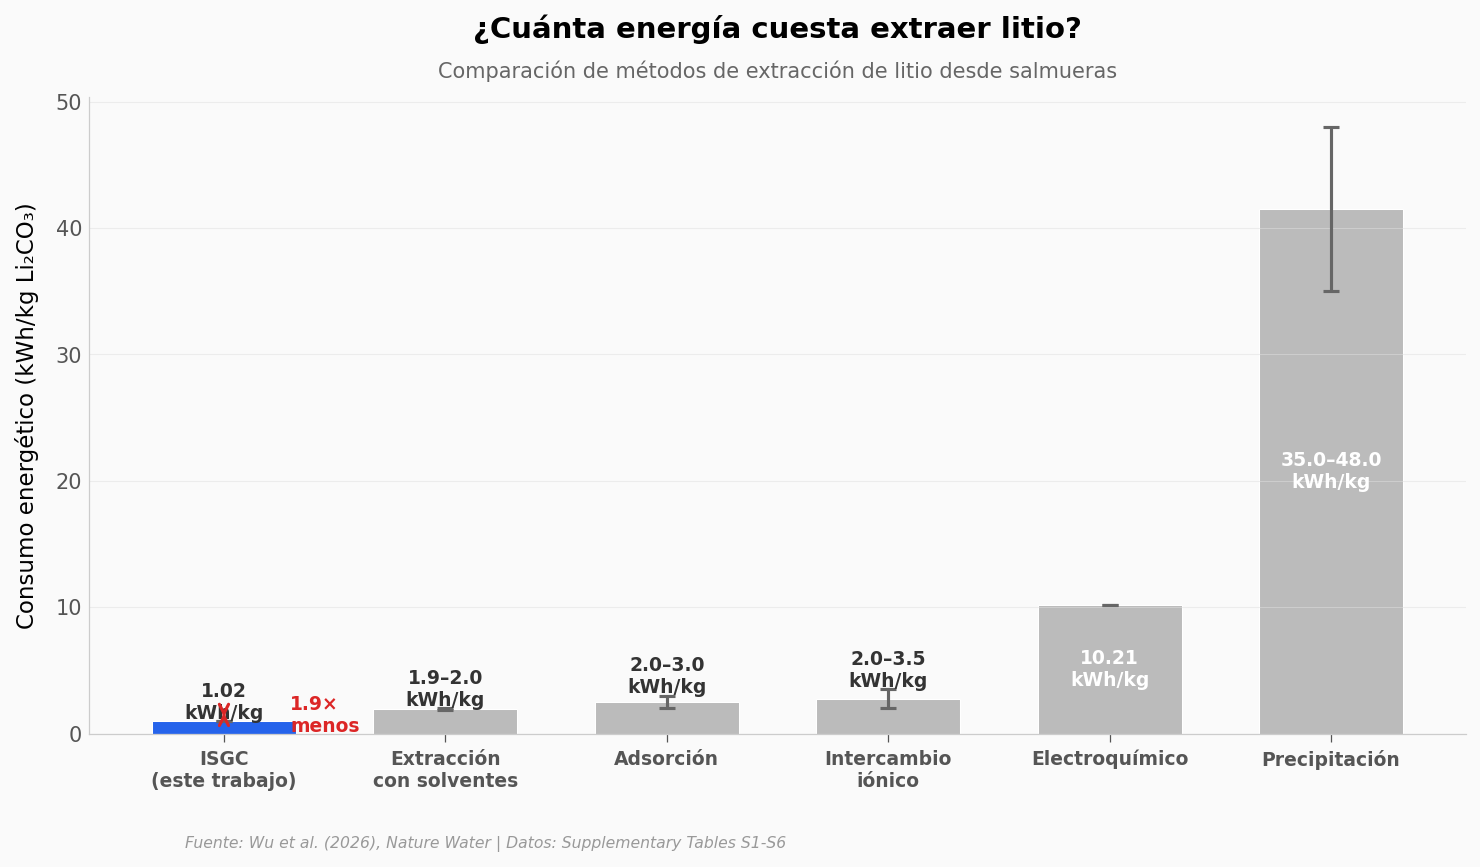

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Usar promedio de rango para comparación justa
metodos_plot = metodos.copy()
metodos_plot['energy_avg'] = metodos_plot[['energy_min_kwh_kg', 'energy_max_kwh_kg']].mean(axis=1)
metodos_plot = metodos_plot.sort_values('energy_avg')

# Nombres en español
nombres = {
    'ISGC (este trabajo)': 'ISGC\n(este trabajo)',
    'Extracción con solventes': 'Extracción\ncon solventes',
    'Intercambio iónico': 'Intercambio\niónico',
    'Adsorción': 'Adsorción',
    'Electroquímico': 'Electroquímico',
    'Precipitación': 'Precipitación'
}
metodos_plot['nombre_corto'] = metodos_plot['metodo'].map(nombres)

colors = [COLOR_ISGC if 'ISGC' in m else COLOR_GRIS for m in metodos_plot['metodo']]

bars = ax.bar(range(len(metodos_plot)), metodos_plot['energy_avg'],
              color=colors, edgecolor='white', linewidth=0.5, width=0.65)

# Error bars para rango
yerr_low = metodos_plot['energy_avg'] - metodos_plot['energy_min_kwh_kg']
yerr_high = metodos_plot['energy_max_kwh_kg'] - metodos_plot['energy_avg']
ax.errorbar(range(len(metodos_plot)), metodos_plot['energy_avg'],
            yerr=[yerr_low.fillna(0), yerr_high.fillna(0)],
            fmt='none', color='#666666', capsize=4, capthick=1.5, linewidth=1.5)

# Inline labels
for i, (_, row) in enumerate(metodos_plot.iterrows()):
    e_min = row['energy_min_kwh_kg']
    e_max = row['energy_max_kwh_kg']
    if e_min == e_max or np.isnan(e_max):
        label = f'{e_min:.2f}'
    else:
        label = f'{e_min:.1f}–{e_max:.1f}'
    color = 'white' if row['energy_avg'] > 8 else '#333333'
    y_pos = row['energy_avg'] / 2 if row['energy_avg'] > 8 else row['energy_max_kwh_kg'] + 1.5
    ax.text(i, y_pos, f'{label}\nkWh/kg', ha='center', va='center',
            fontsize=9, fontweight='bold', color=color)

ax.set_xticks(range(len(metodos_plot)))
ax.set_xticklabels(metodos_plot['nombre_corto'], fontsize=9, fontweight='bold')
ax.set_ylabel('Consumo energético (kWh/kg Li₂CO₃)', fontsize=11)
ax.set_title('¿Cuánta energía cuesta extraer litio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Comparación de métodos de extracción de litio desde salmueras',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Flecha de ahorro
isgc_idx = metodos_plot.index[metodos_plot['metodo'].str.contains('ISGC')].tolist()
isgc_pos = list(metodos_plot['metodo']).index(metodos_plot[metodos_plot['metodo'].str.contains('ISGC')]['metodo'].values[0])
next_pos = isgc_pos + 1 if isgc_pos + 1 < len(metodos_plot) else isgc_pos - 1
next_energy = metodos_plot.iloc[next_pos]['energy_avg']
ax.annotate('', xy=(isgc_pos, ISGC_ENERGY + 0.3),
            xytext=(isgc_pos, next_energy - 0.3),
            arrowprops=dict(arrowstyle='<->', color=COLOR_ALERTA, lw=1.5))
ax.text(isgc_pos + 0.3, (ISGC_ENERGY + next_energy) / 2,
        f'{next_energy/ISGC_ENERGY:.1f}×\nmenos', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold', va='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/energia_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ISGC logra selectividad K⁺/Li⁺ de 410 en multi-ion brines | ✅ | Table S3: K⁺/Li⁺ = 410,1. Abstract confirma "reaching 410 for K⁺/Li⁺" |
| ISGC supera a los 10 competidores comparados en K⁺/Li⁺ | ✅ | 4,8× vs el mejor (UIO-66/ZIF-8 = 85). 60× vs mediana (6,8) |
| Na⁺/Li⁺ de ISGC iguala al mejor competidor | ✅ | ISGC 80,17 vs UIO-66/ZIF-8 80,0 — diferencia <1% |
| El litio hidratado es el catión monovalente más grande | ✅ | Table S2: Li⁺ hydrated = 0,764 nm > Na⁺ (0,716) > K⁺ (0,662) |
| 30% ZIF-8 es la composición óptima | ✅ | Table S1: a 40% el radio salta 1,7× (de 2,686 a 4,592 Å) |
| ISGC consume 1,02 kWh/kg de Li₂CO₃ | ✅ | Table S6 y abstract coinciden: 1,02 kWh/kg |
| ISGC es el método más eficiente energéticamente | ⚠️ | Más bajo que los 5 métodos comparados (siguiente: 1,88 kWh/kg), pero la comparación no incluye todos los métodos existentes |

> **Limitaciones:** Los datos provienen de las tablas del supplementary (Tables S1-S6). Las figuras del paper (no descargables — paywall) contienen datos adicionales de estabilidad temporal, flujo de agua y simulaciones MD que no pudimos reproducir. La selectividad de 410 es en condiciones de laboratorio con salmueras sintéticas; el rendimiento en brines naturales puede diferir.

---

## Ahora tú

1. **¿Qué pasa si cambias la composición?** El notebook carga los 5 puntos de PALS. ¿Podrías interpolar para predecir el radio de poro a 25% ZIF-8?

2. **¿Cuál es el "costo de la selectividad"?** Grafica selectividad K⁺/Li⁺ vs K⁺/Na⁺ para todos los materiales. ¿Los más selectivos en un par lo son en el otro?

3. **¿Cuántos kWh ahorrarías al año?** Si una planta procesa 1.000 kg de Li₂CO₃ al día, calcula el ahorro anual de ISGC vs el segundo método más eficiente.

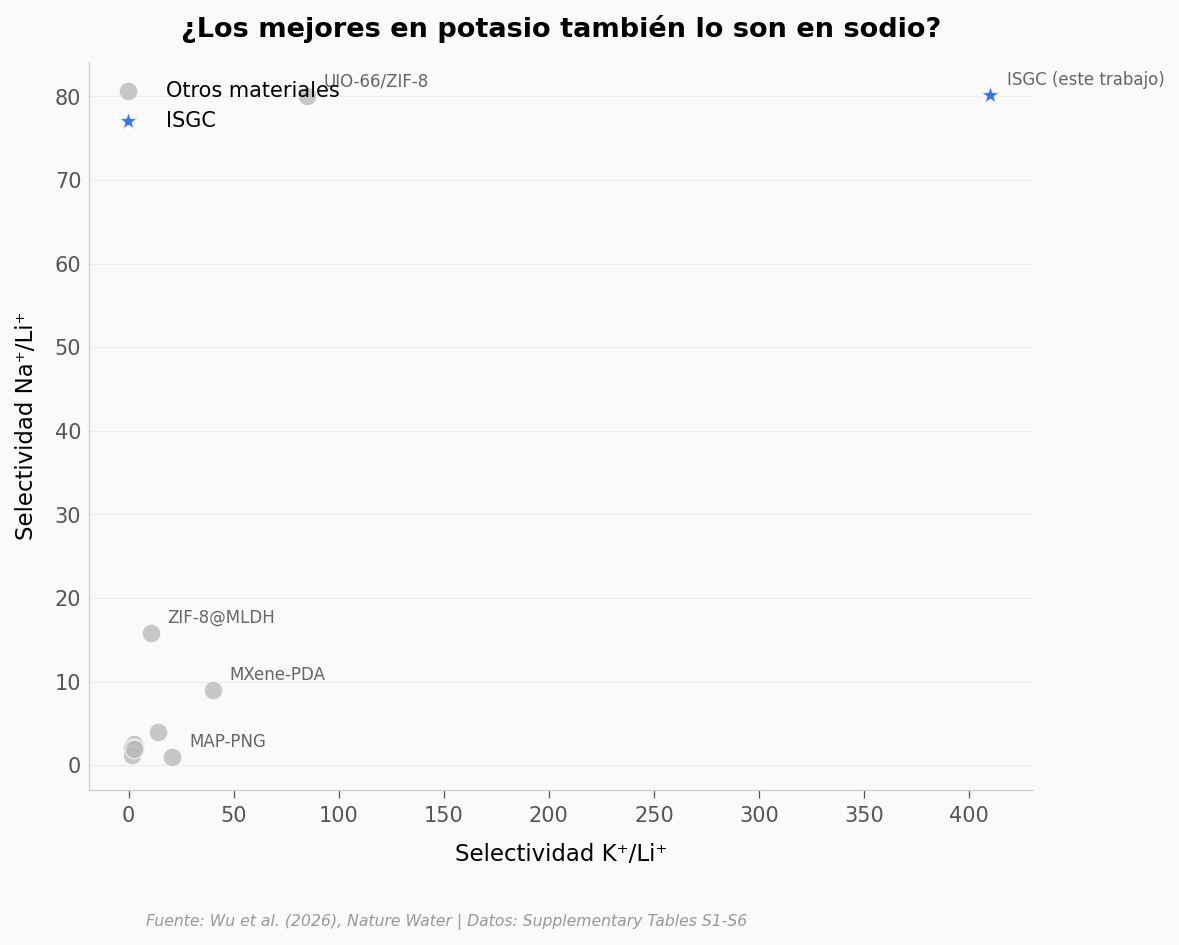

Spearman ρ = 0.636, p = 0.0353, n = 11
→ Correlación significativa


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Existe un trade-off entre selectividad K⁺/Li⁺ y Na⁺/Li⁺?

fig, ax = plt.subplots(figsize=(8, 6))

# Todos los materiales
otros = sel[~sel['material'].str.contains('ISGC')]
isgc = sel[sel['material'].str.contains('ISGC')]

ax.scatter(otros['k_li_selectivity'], otros['na_li_selectivity'],
           s=80, color=COLOR_GRIS, edgecolors='white', linewidths=0.5,
           alpha=0.8, zorder=5, label='Otros materiales')
ax.scatter(isgc['k_li_selectivity'], isgc['na_li_selectivity'],
           s=150, color=COLOR_ISGC, edgecolors='white', linewidths=1.5,
           alpha=0.9, zorder=6, marker='*', label='ISGC')

# Etiquetar algunos
for _, row in sel.iterrows():
    if row['k_li_selectivity'] > 20 or row['na_li_selectivity'] > 10:
        ax.annotate(row['material'], (row['k_li_selectivity'], row['na_li_selectivity']),
                    textcoords='offset points', xytext=(8, 5), fontsize=8, color='#666666')

ax.set_xlabel('Selectividad K⁺/Li⁺', fontsize=11)
ax.set_ylabel('Selectividad Na⁺/Li⁺', fontsize=11)
ax.set_title('¿Los mejores en potasio también lo son en sodio?',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/tradeoff_selectividad.png', dpi=200, bbox_inches='tight')
plt.show()

# ¿Correlación?
from scipy import stats
rho, p = stats.spearmanr(sel['k_li_selectivity'], sel['na_li_selectivity'])
print(f"Spearman ρ = {rho:.3f}, p = {p:.4f}, n = {len(sel)}")
print(f"→ {'Correlación significativa' if p < 0.05 else 'Sin correlación significativa'}")

---

## Créditos

- **Paper:** Wu, J. et al. "Scalable glass composite membranes for highly selective lithium enrichment." *Nature Water* (2026). DOI: [10.1038/s44221-026-00633-w](https://doi.org/10.1038/s44221-026-00633-w)
- **Datos:** Supplementary Tables S1-S6 del paper
- **Licencia datos:** Springer Nature — uso académico y educativo
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)